<a href="https://colab.research.google.com/github/Band3er/course-proj-VR/blob/main/ACV_69170_lab_4_part32_totoro4_small_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratory Session 4: Diffusion models for computer vision**
**Date:** 2 April 2025
   
**Authors**: Jesús Bermúdez Cameo y Alejandro Pérez Yus

**Version:** 1.0

In this lab session we want to explore the mechanisms behind diffusion models for generating, modifying images and connecting them with computer vision inference.

Goals of the assignment:
1.	Understanding Denoising Diffusion Probabilistic Models (DDPM)
2.	Understanding the Latent diffusion models pipeline
3.	Exploring diffusion model applications like depth estimation
4.  Learn to modify whole images and replace masked objects with text prompts

In [ ]:
!pip install torch==2.6.0+cu124 torchvision==0.21.0 torchaudio==2.6.0 -U xformers==0.0.29.post3 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 66.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 824.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1

In [ ]:
!pip install transformers==4.50.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 110.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install torchsde==0.2.6 einops==0.8.1 diffusers==0.32.2 accelerate==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 13.4 MB/s eta 0:00:00
  Attempting uninstall: einops
    Found existing installation: einops 0.8.2
    Uninstalling einops-0.8.2:
      Successfully uninstalled einops-0.8.2
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-0.37.1:
      Successfully uninstalled diffusers-0.37.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0


In [ ]:
%cd /content
!git clone -b totoro4 https://github.com/camenduru/ComfyUI /content/ComfyUI
%cd /content/ComfyUI

!apt -y install -qq aria2

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/flux1-dev-fp8.safetensors -d /content/ComfyUI/models/unet -o flux1-dev-fp8.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/ae.sft -d /content/ComfyUI/models/vae -o ae.sft
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/clip_l.safetensors -d /content/ComfyUI/models/clip -o clip_l.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/camenduru/FLUX.1-dev/resolve/main/t5xxl_fp8_e4m3fn.safetensors -d /content/ComfyUI/models/clip -o t5xxl_fp8_e4m3fn.safetensors


/content
Cloning into '/content/ComfyUI'...
remote: Enumerating objects: 14652, done.
remote: Total 14652 (delta 0), reused 0 (delta 0), pack-reused 14652 (from 1)
Receiving objects: 100% (14652/14652), 21.12 MiB | 15.57 MiB/s, done.
Resolving deltas: 100% (9820/9820), done.
/content/ComfyUI
The following additional packages will be installed:
  libaria2-0 libc-ares2
The following NEW packages will be installed:
  aria2 libaria2-0 libc-ares2
0 upgraded, 3 newly installed, 0 to remove and 30 not upgraded.
Need to get 1,513 kB of archives.
After this operation, 5,441 kB of additional disk space will be used.
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 126213 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../libaria2-0_1.36.0-1_amd64.deb ...
Unpacking

## 3.2 Latent diffusion models for image-to-image (Optional)

In this example we are going to use FLUX1.dev model for image-to-image generation.

In [ ]:
import random
import torch
import numpy as np
from PIL import Image
import nodes
from nodes import NODE_CLASS_MAPPINGS
from totoro_extras import nodes_custom_sampler
from totoro import model_management


The pipeline is going to be quite similar to the previous section but in this case we have to manage the input image.

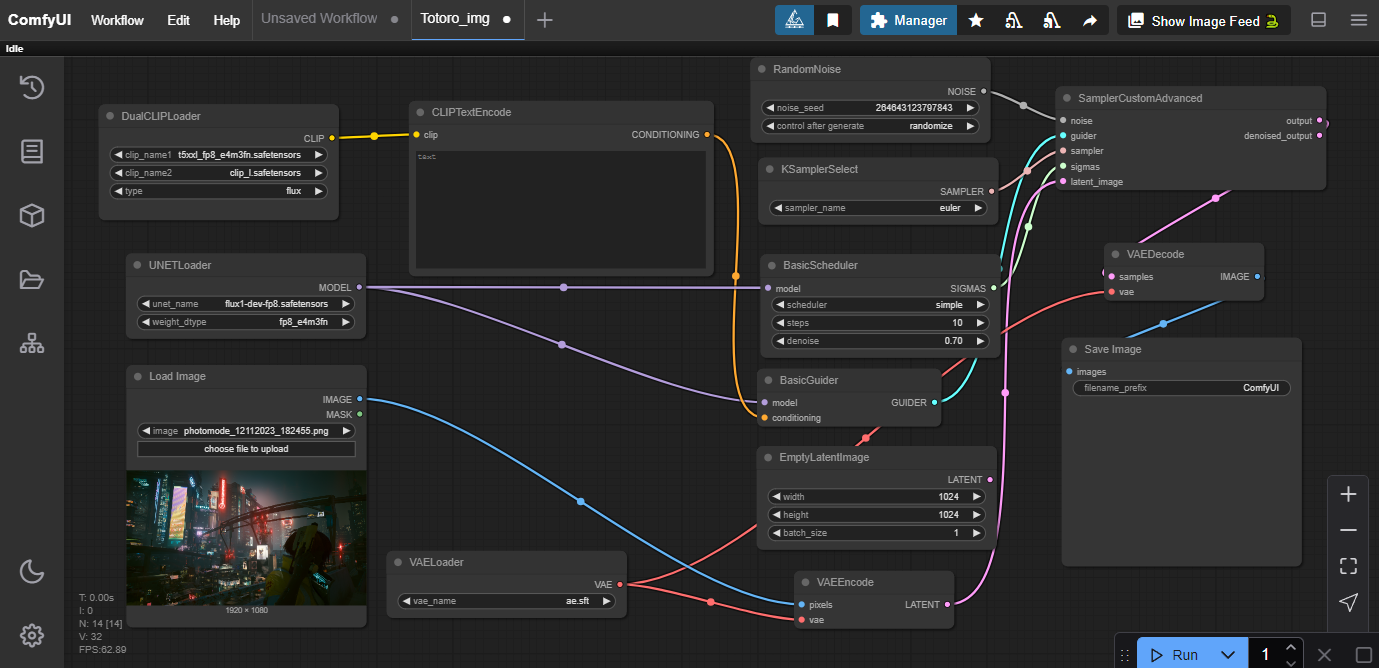

In [ ]:
DualCLIPLoader = NODE_CLASS_MAPPINGS["DualCLIPLoader"]()
UNETLoader = NODE_CLASS_MAPPINGS["UNETLoader"]()
RandomNoise = nodes_custom_sampler.NODE_CLASS_MAPPINGS["RandomNoise"]()
BasicGuider = nodes_custom_sampler.NODE_CLASS_MAPPINGS["BasicGuider"]()
KSamplerSelect = nodes_custom_sampler.NODE_CLASS_MAPPINGS["KSamplerSelect"]() #sampling/custom_sampling
BasicScheduler = nodes_custom_sampler.NODE_CLASS_MAPPINGS["BasicScheduler"]()
SamplerCustomAdvanced = nodes_custom_sampler.NODE_CLASS_MAPPINGS["SamplerCustomAdvanced"]()
VAELoader = NODE_CLASS_MAPPINGS["VAELoader"]()
VAEEncode = NODE_CLASS_MAPPINGS["VAEEncode"]()
VAEDecode = NODE_CLASS_MAPPINGS["VAEDecode"]()
EmptyLatentImage = NODE_CLASS_MAPPINGS["EmptyLatentImage"]()

In [ ]:
with torch.inference_mode():
    unet = UNETLoader.load_unet("flux1-dev-fp8.safetensors", "fp8_e4m3fn")[0]

In [ ]:
with torch.inference_mode():
    vae = VAELoader.load_vae("ae.sft")[0]

In [ ]:
with torch.inference_mode():
    clip = DualCLIPLoader.load_clip("t5xxl_fp8_e4m3fn.safetensors", "clip_l.safetensors", "flux")[0]

In [ ]:
import random
import torch
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

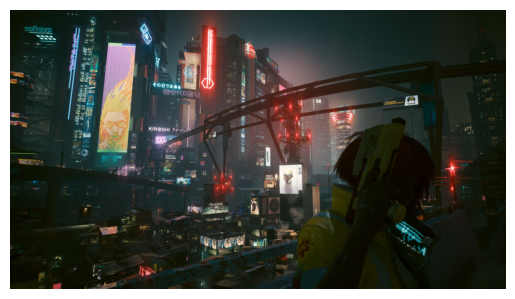

In [ ]:
img_pil = Image.open('/content/photomode_12112023_182455_red_red.png').convert("RGB")

img_in = np.array(img_pil).astype(np.float32) / 255.0
img_in = torch.from_numpy(img_in)[None,]

plt.figure()
plt.imshow(img_in[0,:,:,:])
plt.axis('off')
plt.show()

In [ ]:
positive_prompt = 'A girl standing on the right side of the frame and looking to the right, with a cyberpunk-city landscape in the background, both in sharp focus. Anime cyberpunk style. High detail, 4K resolution.'

17019484941469500459


In [ ]:
with torch.inference_mode():
    cond, pooled = clip.encode_from_tokens(clip.tokenize(positive_prompt), return_pooled=True)
    cond = [[cond, {"pooled_output": pooled}]]


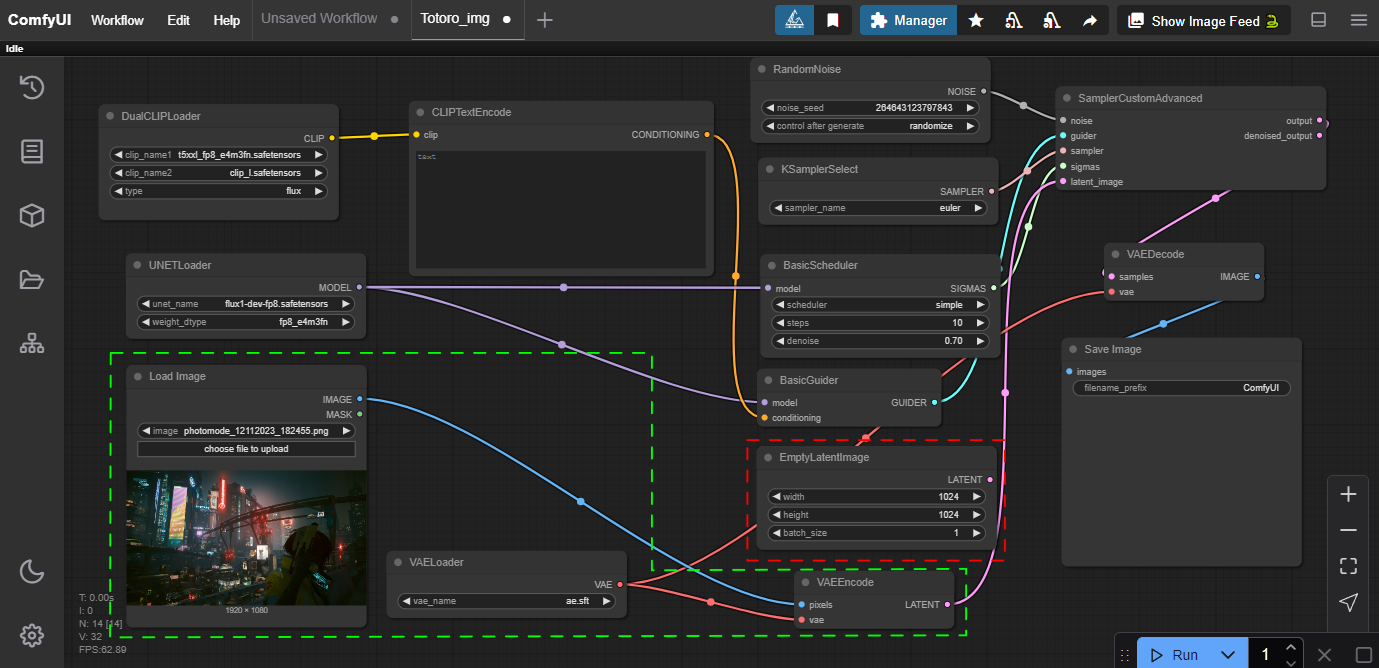

For image-to-image methods we ideally would like to condition the diffusion denoising with the input image. Since Flux1.dev is a text-to-image method we can try some trick. Instead of starting from a random latent image in the latent space we can begin from the latent-encoding of the input image. For that in this case we can reduce the `denoise` parameter to avoid the denoiser the latent image too much.

**Task:** Substitute the `EmptyLatentImage`module by the encoder of the VAE. The `VAEEncode.encode` function receive as input parameters the `vae` and the input image `img_in` and return a `latent` inside a one-value list.

In [ ]:
with torch.inference_mode():
# COMPLETE HERE
     #latent = ...
#END COMPLETE HERE

In [ ]:
seed = 17019484941469500459
steps = 10
sampler_name = "euler"
scheduler = "simple"
denoise = 0.5574118097656251
if seed == 0:
    seed = random.randint(0, 18446744073709551615)
print(seed)

In [ ]:
with torch.inference_mode():
    noise = RandomNoise.get_noise(seed)[0]
    guider = BasicGuider.get_guider(unet, cond)[0]
    sampler = KSamplerSelect.get_sampler(sampler_name)[0]
    sigmas = BasicScheduler.get_sigmas(unet, scheduler, steps, denoise)[0]
    sample, sample_denoised = SamplerCustomAdvanced.sample(noise, guider, sampler, sigmas, latent)
    model_management.soft_empty_cache()

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
with torch.inference_mode():
    decoded = VAEDecode.decode(vae, sample)[0].detach()

(np.float64(-0.5), np.float64(959.5), np.float64(535.5), np.float64(-0.5))

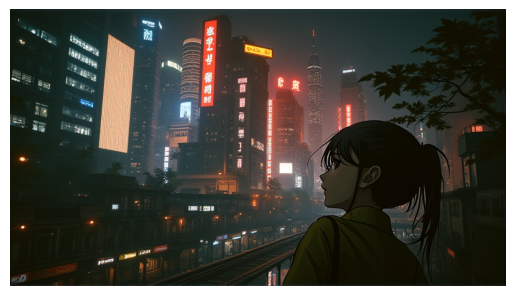

In [ ]:
Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0]).save("./cbpunk_01.png")
img_out = np.array(decoded*255, dtype=np.uint8)[0]

plt.imshow(img_out)
plt.axis('off')